In [1]:
import numpy as np
import xarray as xr

import cartopy
import matplotlib as mpl
import matplotlib.pyplot as plt

In [2]:
dataset_path = "E:/dataset"
hindcast_ds = xr.open_dataset(f"{dataset_path}/mx_secihti_cicese_hindcast_sst_nep_0p10deg_185001-202508_v1.nc")
hindcast_ds

c:\Users\USER\anaconda3\lib\site-packages\xarray\backends\plugins.py:80: RuntimeWarning: Engine 'gini' loading failed:
No module named 'pooch'
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)


<xarray.Dataset> Size: 1GB
Dimensions:       (time: 2108, lat: 351, lon: 351)
Coordinates:
  * time          (time) datetime64[ns] 17kB 1850-01-01 ... 2025-08-01
  * lat           (lat) float32 1kB 20.0 20.1 20.2 20.3 ... 54.7 54.8 54.9 55.0
  * lon           (lon) float32 1kB -140.0 -139.9 -139.8 ... -105.1 -105.0
Data variables:
    sst_hindcast  (time, lat, lon) float32 1GB ...
Attributes: (12/14)
    title:               High-resolution SST hindcast over the Northeast Paci...
    summary:             Monthly sea surface temperature (SST) hindcast gener...
    institution:         SECIHTI / CICESE-UALP
    source:              GAM-based statistical hindcast of SST
    history:             Created on 2026-02-12T07:42:26.470276
    references:          
    ...                  ...
    lat_min:             20.0
    lat_max:             55.0
    lon_min:             -140.0
    lon_max:             -105.0
    time_start:          1850-01-01T00:00:00.000000000
    time_end:            2025-08-01T00:00:00.000000000

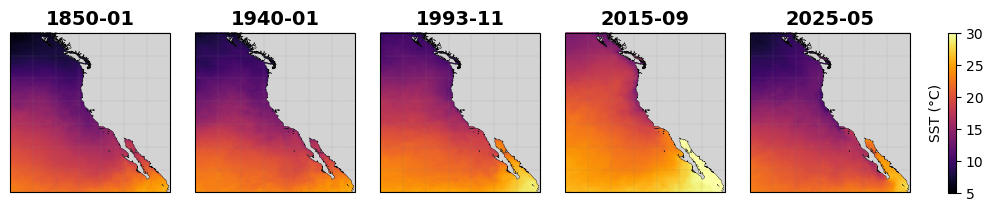

In [3]:
dates = ["1850-01-01","1940-01-01","1993-11-01","2015-09-01","2025-05-01"]

fig = plt.figure(figsize=(10, 2), constrained_layout=True)
cmap = mpl.cm.get_cmap("inferno")

for k in range(len(dates)):
    idx = np.where(hindcast_ds.time.values == np.datetime64(dates[k]))[0][0]
    
    ax = fig.add_subplot(1, len(dates), k+1, projection=cartopy.crs.PlateCarree())
    land = cartopy.feature.NaturalEarthFeature('physical', 'land', scale="10m", edgecolor='k', facecolor=cartopy.feature.COLORS['land'])
    ax.add_feature(land, facecolor='lightgray', linewidth=0.25)
    gl = ax.gridlines(crs=cartopy.crs.PlateCarree(), draw_labels=False, linewidth=0.25, color='gray', alpha=0.5, linestyle='--')

    pc = ax.pcolor(hindcast_ds.lon, hindcast_ds.lat, hindcast_ds.sst_hindcast.data[idx,:,:], cmap=cmap, vmin=5, vmax=30)
    ax.set_title(dates[k][:7], fontweight="bold", fontsize=14)

cbar = fig.colorbar(pc, ax=fig.axes, pad=0.02)
cbar.set_label("SST (°C)")
cbar.ax.yaxis.set_label_position("left")
plt.show()